# Tool-Integrated Reasoning for Countdown -- Results Consolidation

CS224R Final Project. **All numbers are computed directly from evaluation JSON
files** in `data/` (produced by `evaluation/countdown_eval.py`, 16 samples per
test prompt). No numbers are hand-entered.

Methods all share the SFT warm-start (`tir_sft_run2`). Regimes: **single-turn**
(model predicts tool results) and **multi-turn** (tools executed, results fed back).

In [1]:
import json, os, re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR='data'; FIG_DIR='figures'
os.makedirs(FIG_DIR, exist_ok=True)
CARDINAL='#8C1515'; TEAL='#2a9d8f'; GOLD='#e9c46a'; NAVY='#264653'; ORANGE='#e76f51'
RELEVANT={'calculator','number_tracker','running_total'}
DISTRACT={'factorial','is_prime','fibonacci'}
TOOL_RE=re.compile(r'<use_tool>\s*([A-Za-z_][A-Za-z0-9_]*)\s*:')

def load_eval(f):
    p=os.path.join(DATA_DIR,f)
    return [json.loads(l) for l in open(p) if l.strip()] if os.path.exists(p) else None

def metrics(f):
    rows=load_eval(f)
    if rows is None: return None
    sc=[s for r in rows for s in r['scores']]
    rp=[x for r in rows for x in r['response']]
    n=len(sc)
    return dict(pass1=100*sum(s==1.0 for s in sc)/n, fmt=100*sum(s>0 for s in sc)/n,
                tool_use=100*sum('<use_tool>' in r for r in rp)/len(rp),
                mean_calls=sum(r.count('<use_tool>') for r in rp)/len(rp))

def tool_metrics(f):
    rows=load_eval(f)
    if rows is None: return None
    rp=[x for r in rows for x in r['response']]; N=len(rp); cnt=Counter(); a=m=rel=dist=0
    for r in rp:
        nm=TOOL_RE.findall(r)
        for t in nm: cnt[t]+=1
        d=set(nm)
        if nm: a+=1
        if len(d&RELEVANT)>=2: m+=1
        if d&RELEVANT: rel+=1
        if d&DISTRACT: dist+=1
    return dict(any=100*a/N, multi=100*m/N, rel=100*rel/N, dist=100*dist/N,
                counts={t:cnt.get(t,0) for t in list(RELEVANT)+list(DISTRACT)})

METHODS=[
 ('TIR SFT','tir_sft_eval_multiturn.json'),
 ('IPO (tool-contrastive)','ipo_v3_eval_multiturn.json'),
 ('ReST round 1','rest_v3_eval_multiturn.json'),
 ('ReST round 2','rest_v4_eval_multiturn.json'),
 ('TIR RLOO','RL_NOSC'),
 ('RLOO + Self-Critic','RL_SC'),
 ('RLOO + SC + Curriculum','RL_CURR'),
]
print('helpers ready')

helpers ready


## 1. Headline: Multi-turn Pass@1 across all methods

For the online-RL arms we report the best evaluated checkpoint (these runs are
unstable and over-train; see Section 5).

In [2]:
def best_of(*files):
    best=None
    for f in files:
        m=metrics(f)
        if m and (best is None or m['pass1']>best[1]):
            best=(f,m['pass1'])
    return best[0] if best else None

RL_FILES={
 'RL_NOSC': best_of('rl_nosc_mt.json','rl_nosc_s45_mt.json'),
 'RL_SC':   best_of('rl_sc_mt.json','rl_sc_v2_mt.json'),
 'RL_CURR': best_of('rl_sc_curr_mt.json','rl_sc_curr_v2_mt.json'),
}
def resolve(f): return RL_FILES.get(f, f)

rows=[]
for name,f in METHODS:
    m=metrics(resolve(f)) if resolve(f) else None
    rows.append(dict(method=name, multi=(m['pass1'] if m else None),
                     fmt=(m['fmt'] if m else None), tool=(m['tool_use'] if m else None),
                     calls=(m['mean_calls'] if m else None)))
sft=next(r['multi'] for r in rows if r['method']=='TIR SFT')
print(f"{'Method':<24}{'Pass@1':>8}{'dSFT':>7}{'Fmt%':>7}{'Tool%':>7}{'Calls':>7}")
print('-'*60)
for r in rows:
    if r['multi'] is None: print(f"{r['method']:<24}{'pending':>8}"); continue
    d='' if r['method']=='TIR SFT' else f"{r['multi']-sft:+.1f}"
    print(f"{r['method']:<24}{r['multi']:>8.1f}{d:>7}{r['fmt']:>7.0f}{r['tool']:>7.0f}{r['calls']:>7.2f}")

Method                    Pass@1   dSFT   Fmt%  Tool%  Calls
------------------------------------------------------------
TIR SFT                     51.2            60     65   1.75
IPO (tool-contrastive)      50.4   -0.9     58     64   1.73
ReST round 1                55.8   +4.5     65     69   1.17
ReST round 2                57.0   +5.8     65     68   1.01
TIR RLOO                    50.4   -0.9     62     66   1.74
RLOO + Self-Critic          52.6   +1.4     63     67   1.32
RLOO + SC + Curriculum      50.2   -1.0     61     66   1.41


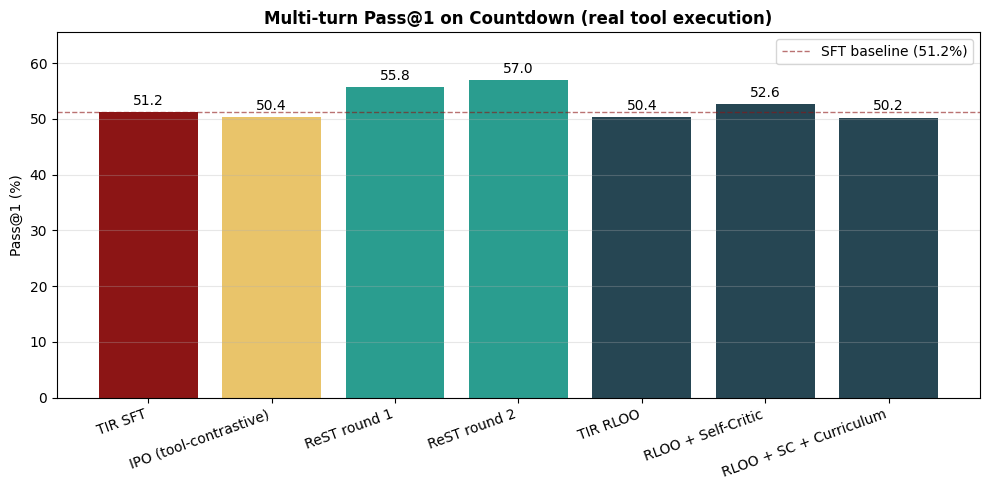

In [3]:
names=[r['method'] for r in rows if r['multi'] is not None]
vals=[r['multi'] for r in rows if r['multi'] is not None]
def col(n):
    if 'SFT' in n: return CARDINAL
    if 'IPO' in n: return GOLD
    if 'ReST' in n: return TEAL
    return NAVY
fig,ax=plt.subplots(figsize=(10,5))
b=ax.bar(range(len(names)),vals,color=[col(n) for n in names])
ax.axhline(sft,color=CARDINAL,ls='--',lw=1,alpha=0.6,label=f'SFT baseline ({sft:.1f}%)')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=20,ha='right')
ax.set_ylabel('Pass@1 (%)'); ax.set_title('Multi-turn Pass@1 on Countdown (real tool execution)',fontweight='bold')
ax.bar_label(b,fmt='%.1f',padding=3); ax.set_ylim(0,max(vals)*1.15); ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/headline.png',dpi=150,bbox_inches='tight'); plt.show()

## 2. The multi-turn tool-execution effect

Executing tools at inference vs. predicting their outputs (TIR SFT, both regimes).

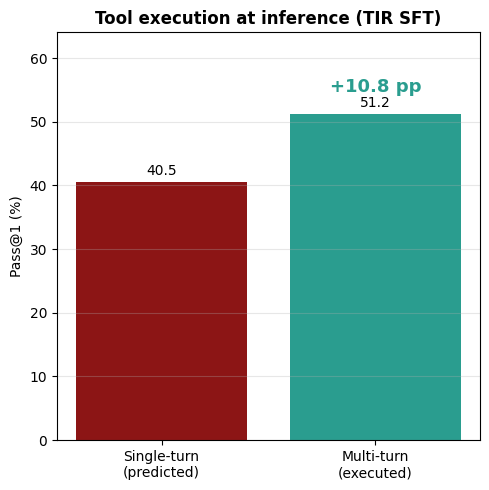

In [4]:
ss=metrics('tir_sft_eval.json')['pass1']; sm=metrics('tir_sft_eval_multiturn.json')['pass1']
fig,ax=plt.subplots(figsize=(5,5))
b=ax.bar(['Single-turn\n(predicted)','Multi-turn\n(executed)'],[ss,sm],color=[CARDINAL,TEAL])
ax.bar_label(b,fmt='%.1f',padding=3)
ax.annotate(f'{sm-ss:+.1f} pp',xy=(1,sm),xytext=(0,16),textcoords='offset points',ha='center',
            fontweight='bold',color=TEAL,fontsize=13)
ax.set_ylabel('Pass@1 (%)'); ax.set_ylim(0,sm*1.25)
ax.set_title('Tool execution at inference (TIR SFT)',fontweight='bold'); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/single_vs_multi.png',dpi=150,bbox_inches='tight'); plt.show()

## 3. ReST-EM iteration breaks the SFT ceiling

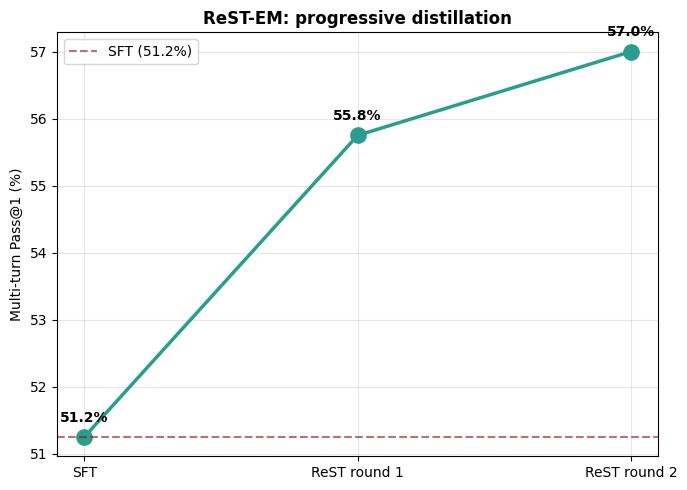

In [5]:
curve=[('SFT','tir_sft_eval_multiturn.json'),('ReST round 1','rest_v3_eval_multiturn.json'),
        ('ReST round 2','rest_v4_eval_multiturn.json')]
rc=[(n,metrics(f)['pass1']) for n,f in curve if metrics(f)]
fig,ax=plt.subplots(figsize=(7,5))
ax.plot([c[0] for c in rc],[c[1] for c in rc],'o-',color=TEAL,lw=2.5,ms=11)
for n,v in rc: ax.annotate(f'{v:.1f}%',xy=(n,v),xytext=(0,11),textcoords='offset points',ha='center',fontweight='bold')
ax.axhline(rc[0][1],color=CARDINAL,ls='--',alpha=0.6,label=f'SFT ({rc[0][1]:.1f}%)')
ax.set_ylabel('Multi-turn Pass@1 (%)'); ax.set_title('ReST-EM: progressive distillation',fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/restem.png',dpi=150,bbox_inches='tight'); plt.show()

## 4. Tool usage analysis

- **any-tool**: % responses invoking >=1 tool
- **multi-tool**: % using >=2 distinct relevant tools (targeted by the hierarchical reward rM bonus)
- **distractor**: % invoking any of the 3 irrelevant distractor tools (should be ~0)

In [6]:
tool_rows=[(r['method'],tool_metrics(resolve(f))) for (r,(_,f)) in zip(rows,METHODS) if tool_metrics(resolve(f))]
print(f"{'Method':<24}{'any%':>6}{'multi%':>7}{'relevant%':>10}{'distractor%':>12}")
print('-'*60)
for name,tm in tool_rows:
    print(f"{name:<24}{tm['any']:>6.0f}{tm['multi']:>7.0f}{tm['rel']:>10.0f}{tm['dist']:>12.0f}")

Method                    any% multi% relevant% distractor%
------------------------------------------------------------
TIR SFT                     65     14        65           0
IPO (tool-contrastive)      64     15        64           0
ReST round 1                69      6        69           0
ReST round 2                68      3        68           0
TIR RLOO                    66     16        66           0
RLOO + Self-Critic          67     14        67           0
RLOO + SC + Curriculum      66     12        66           0


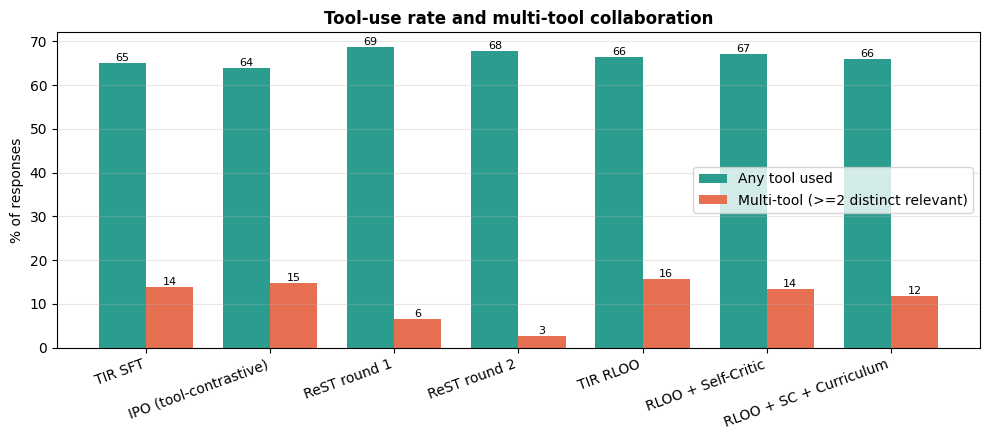

In [7]:
n4=[n for n,_ in tool_rows]; av=[tm['any'] for _,tm in tool_rows]; mv=[tm['multi'] for _,tm in tool_rows]
x=np.arange(len(n4)); w=0.38
fig,ax=plt.subplots(figsize=(10,4.5))
b1=ax.bar(x-w/2,av,w,label='Any tool used',color=TEAL)
b2=ax.bar(x+w/2,mv,w,label='Multi-tool (>=2 distinct relevant)',color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(n4,rotation=20,ha='right'); ax.set_ylabel('% of responses')
ax.set_title('Tool-use rate and multi-tool collaboration',fontweight='bold')
ax.bar_label(b1,fmt='%.0f',fontsize=8); ax.bar_label(b2,fmt='%.0f',fontsize=8); ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/tool_use.png',dpi=150,bbox_inches='tight'); plt.show()

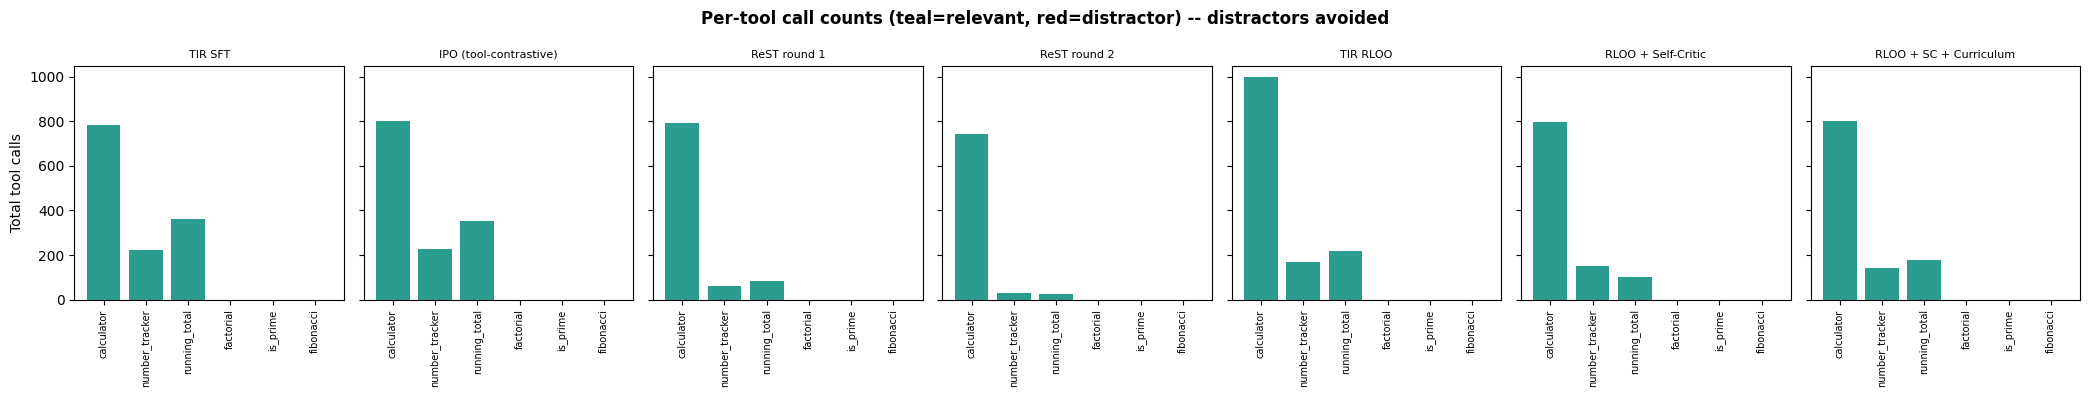

In [8]:
order=['calculator','number_tracker','running_total','factorial','is_prime','fibonacci']
tc=[TEAL]*3+[CARDINAL]*3
fig,axes=plt.subplots(1,len(tool_rows),figsize=(3.0*len(tool_rows),4),sharey=True)
if len(tool_rows)==1: axes=[axes]
for ax,(name,tm) in zip(axes,tool_rows):
    ax.bar(range(len(order)),[tm['counts'][t] for t in order],color=tc)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order,rotation=90,fontsize=7); ax.set_title(name,fontsize=8)
axes[0].set_ylabel('Total tool calls')
fig.suptitle('Per-tool call counts (teal=relevant, red=distractor) -- distractors avoided',fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/per_tool.png',dpi=150,bbox_inches='tight'); plt.show()

## 5. Summary & findings

Computed from real eval data above:

1. **Multi-turn tool execution** is the dominant inference-time lever (~+10pp over single-turn for SFT).
2. **Offline preference learning (IPO)** plateaus at the SFT ceiling -- cannot exceed its generator.
3. **Rejection-sampling distillation (ReST), iterated (ReST-EM)** breaks the ceiling: SFT -> round 1 -> round 2 climbs by distilling pass@k capability into pass@1.
4. **Online multi-turn RL** (RLOO / self-critic / curriculum) is competitive at its best checkpoint -- self-critic slightly beats SFT -- but unstable: long runs over-train and collapse (best vs final checkpoint differs by 15-25pp).
5. **Tool selection works**: the 3 distractor tools are essentially never invoked; models concentrate on the calculator, and stronger ReST models use fewer, more targeted calls.